# Proyecto - Computación Avanzada

## Estudio de caso para 4 poblaciones (2 depredadores y 2 presas)

In [ ]:
from pesca_env import Pesca4D
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.env_util import make_vec_env

In [2]:
"""
Orden de los datos
[Presa1, Presa2, Depredador1, Depredador2]
"""

#Factor de crecimiento de cada poblacion
r = np.array([0.9, 0.7, 0.3, 0.2])

#Factor de ruido agregado al sistema
sigma = 0.05

#Poblacion inicial de cada especie
init_B = np.array([0.4, 0.7, 0.1, 0.2])

#Factor terminated
T = 200

#Factor de mortalidad de cada especie
mort = [0.1, 0.2, 0.3, 0.02]

#Factor de arrastre para presas y cazadores
arrastre = [0.1, 0.2]

#Factor que limita el valor maximo de la poblacion depredadora
C = 1

observables = np.array([0])

#Diccionario con los parametros del env
params = { "r_crecimiento": r,
           "sigma": sigma,
           "init_B": init_B,
           "T": T,
           "mortalidad": mort,
           "C": C,
           "epsilon": 1e-5,
           "arrastre": arrastre,
           "observables": observables
}

In [ ]:
def init_agent(env, model, training=False, name="pesca_4D"):
    if training == True:
        #Inicializa el modelo
        if model == "RecurrentPPO":
            agent = RecurrentPPO("MlpLstmPolicy", env, verbose=1, device="cpu")
        
            #Entrena el modelo
            agent.learn(total_timesteps=5000)
        
            #Guarda el modelo
            agent.save("RecurrentPPO_" + name)

        elif model == "PPO":
            #Inicializa el modelo
            agent = PPO("MlpPolicy", env, verbose=1, device="cpu")
            
            #Entrena el modelo
            agent.learn(total_timesteps=25000)
            
            #Guarda el modelo
            agent.save("PPO_" + name)  

    else:
        if model == "RecurrentPPO":
            #Carga el modelo
            agent = RecurrentPPO.load("RecurrentPPO_" + name, device="cpu")
            
        elif model == "PPO":
            #Carga el modelo
            agent = PPO.load("PPO_" + name, device="cpu")
        
    return agent

In [ ]:
def time_evolution(env, agent, model, N=200, accion=True):
    #Reinicia el environment
    obs, _ = env.reset()

    #Guarda la evolucion de las poblaciones
    data_B = np.zeros((N,len(env.B)))
    rewards = np.zeros(N)    

    if model == "RecurrentPPO":
        lstm_states = None
        episode_starts = np.ones((1,), dtype=bool)

    #Evolucion natural
    if accion != True:
        for i in range(N):
            
            action = np.array([-1])
            
            #Calcula un step del environment segun la acción
            obs, reward, terminated, truncated, _ = env.step(action)

            #Registra la población de cada paso
            data_B[i] = env.B.copy()
        
            #Registra los rewards de cada paso
            rewards[i] = reward
        
    else:
        if model == "PPO":
            
            for i in range(N):
                #Realiza la accion del modelo PPO
                action, _ = agent.predict(obs, deterministic=True)

                #Calcula un step del environment segun la acción
                obs, reward, terminated, truncated, _ = env.step(action)

                #Registra la población de cada paso
                data_B[i] = env.B.copy()
    
                #Registra los rewards de cada paso
                rewards[i] = reward        
        
        elif model == "RecurrentPPO":
            for i in range(N):
                #Realiza la accion del modelo PPO
                action, lstm_states = agent.predict(
                    obs,
                    state=lstm_states,
                    episode_start=episode_starts,
                    deterministic=True
                )

                episode_starts = np.zeros((1,), dtype=bool)

                #Calcula un step del environment segun la acción
                obs, reward, terminated, truncated, _ = env.step(action)

                if terminated or truncated:
                    episode_starts = np.ones((1,), dtype=bool)
            
                #Registra la población de cada paso
                
                data_B[i] = env.B.copy()
                
            
                #Registra los rewards de cada paso
                rewards[i] = reward
    
    return data_B, rewards

In [8]:
#Inicializa el ambiente
env = Pesca4D(params)

#Inicializa el agente
agentPPO = init_agent(env,"PPO", training=False)
agentRecPPO = init_agent(env, "RecurrentPPO", training=False)

data_B_PPO, rewards_PPO = time_evolution(env,agentPPO,"PPO")
data_B_RecPPO, rewards_RecPPO = time_evolution(env,agentRecPPO,"RecurrentPPO")

## Resultados: Evolución temporal de la población y del harvest

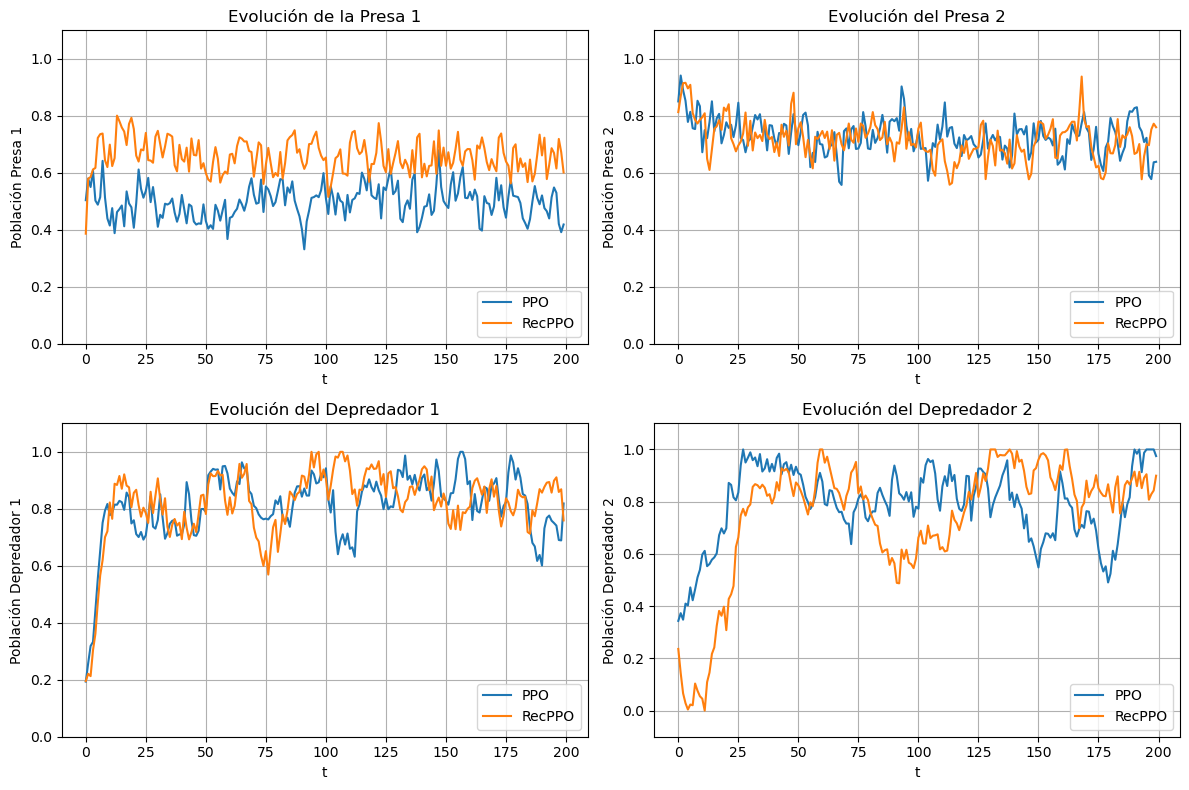

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Gráfica de Población1
axs[0, 0].plot(data_B_PPO[:,0], label="PPO")
axs[0, 0].plot(data_B_RecPPO[:,0], label="RecPPO")
axs[0, 0].set_xlabel("t")
axs[0, 0].set_ylabel("Población Presa 1")
axs[0, 0].set_title("Evolución de la Presa 1")
axs[0, 0].grid(True)
axs[0, 0].set_ylim([0,1.1])
axs[0, 0].legend(loc="lower right")

# Gráfica de Población2
axs[0, 1].plot(data_B_PPO[:,1], label="PPO")
axs[0, 1].plot(data_B_RecPPO[:,1], label="RecPPO")
axs[0, 1].set_xlabel("t")
axs[0, 1].set_ylabel("Población Presa 2")
axs[0, 1].set_title("Evolución del Presa 2")
axs[0, 1].grid(True)
axs[0, 1].set_ylim([0,1.1])
axs[0, 1].legend(loc="lower right")

# Gráfica de Depredador1
axs[1, 0].plot(data_B_PPO[:,2], label="PPO")
axs[1, 0].plot(data_B_RecPPO[:,2], label="RecPPO")
axs[1, 0].set_xlabel("t")
axs[1, 0].set_ylabel("Población Depredador 1")
axs[1, 0].set_title("Evolución del Depredador 1")
axs[1, 0].grid(True)
axs[1, 0].set_ylim([0,1.1])
axs[1, 0].legend(loc="lower right")

# Gráfica de Depredador2
axs[1, 1].plot(data_B_PPO[:,3], label="PPO")
axs[1, 1].plot(data_B_RecPPO[:,3], label="RecPPO")
axs[1, 1].set_xlabel("t")
axs[1, 1].set_ylabel("Población Depredador 2")
axs[1, 1].set_title("Evolución del Depredador 2")
axs[1, 1].grid(True)
axs[1, 1].set_ylim([-0.1,1.1])
axs[1, 1].legend(loc="lower right")

plt.tight_layout()
plt.show()